<a href="https://colab.research.google.com/github/MaeSantos/CCADMACL_EXERCISES_COM231/blob/main/Exercise2B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EXERCISE 2B

Imagine you are a data scientist working for an international development organization. Your team wants to understand how countries differ in terms of economy, health, and social well-being. You have access to a dataset containing multiple indicators for countries worldwide, such as GDP per capita, life expectancy, child mortality, and population.

Your task is to discover natural groupings of countries using hierarchical clustering. By examining these clusters, you can identify patterns such as:

- Which countries are economically developed or developing

- How social and health indicators vary across regions

- Surprising similarities between countries from different continents

Answer each question by completing the corresponding code cell. **Do not remove or reorder cells.**


In [42]:
import kagglehub
import os
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("rohan0301/unsupervised-learning-on-country-data")

print("Path to dataset files:", path)

if os.path.isdir(path):
  print(True)

contents = os.listdir(path)
# The actual data file is 'Country-data.csv', which is contents[1]
mydataset = path + "/" + contents[1]
mydataset


df = pd.read_csv(mydataset)

Using Colab cache for faster access to the 'unsupervised-learning-on-country-data' dataset.
Path to dataset files: /kaggle/input/unsupervised-learning-on-country-data
True


## 1. Import Required Libraries
Import the core libraries needed for data analysis, visualization, and clustering.

In [43]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering


## 2. Load the Dataset
Upload the CSV file for *the* **Country Data** dataset.

In [44]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rohan0301/unsupervised-learning-on-country-data")

print("Path to dataset files:", path)

if os.path.isdir(path):
  print(True)

contents = os.listdir(path)
contents

mydataset = path + "/" + contents[0]
mydataset


df = pd.read_csv(mydataset)


Using Colab cache for faster access to the 'unsupervised-learning-on-country-data' dataset.
Path to dataset files: /kaggle/input/unsupervised-learning-on-country-data
True


## 3. Exploring the Dataset

Display the first 10 rows of the dataset `(5 pts)`

- Show the initial records to understand the dataset's structure and variables.

In [45]:
df.head(10)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


Display the shape of the dataset `(5 pts)`
- How many rows (countries) and how many features does the dataset contain?

In [46]:
df.shape

(167, 10)

Show summary statistics using `describe()`. `(5 pts)`

In [47]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


Check for missing values. `(5 pts)`

In [48]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


## 4. Data Preprocessing

Select only the numerical columns for clustering `(5 pts)`
- Exclude any non-numeric fields, such as 'Country Name' or categorical variables.

In [49]:
numerical = df.select_dtypes(include=['number'])
numerical

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...
162,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [50]:
df.isna().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


Standardize the selected numerical features `(5 pts)`

- This ensures all features contribute equally to the distance calculations used in clustering.

In [60]:
scaler = StandardScaler()
scaled_numerical = scaler.fit_transform(numerical)
scaled_numerical = pd.DataFrame(scaled_numerical, columns=numerical.columns)

## 5. Exploratory Data Analysis

Generate a correlation heatmap
- Visualize the relationships between socioeconomic indicators. `(10 pts)`

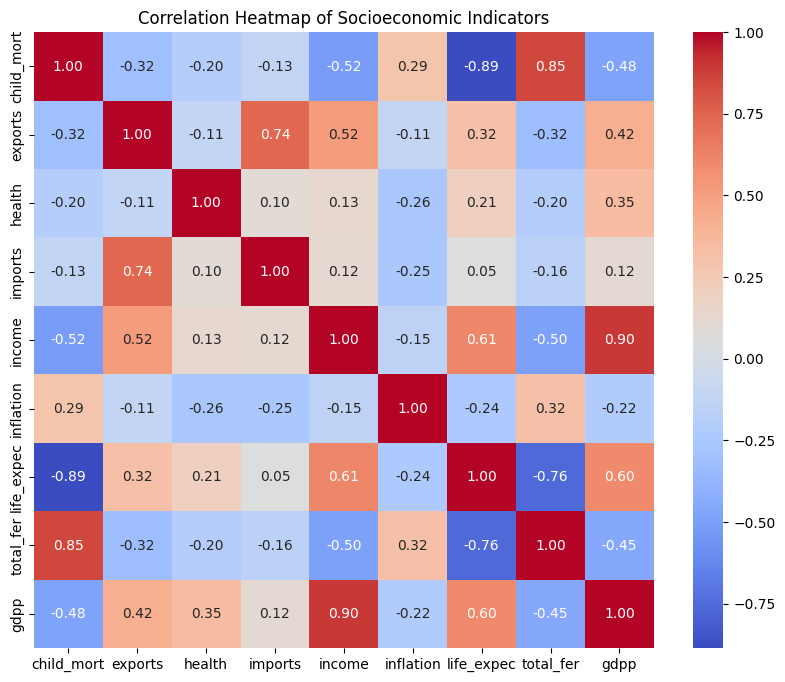

In [52]:
plt.figure(figsize=(10, 8))
sns.heatmap(scaled_numerical.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Socioeconomic Indicators')
plt.show()

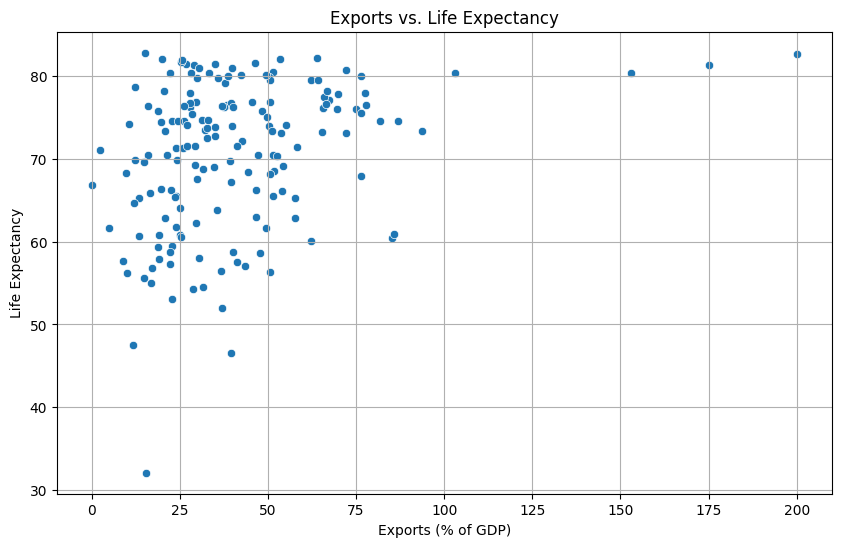

In [58]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='exports', y='life_expec', data=df)
plt.title('Exports vs. Life Expectancy')
plt.xlabel('Exports (% of GDP)')
plt.ylabel('Life Expectancy')
plt.grid(True)
plt.show()

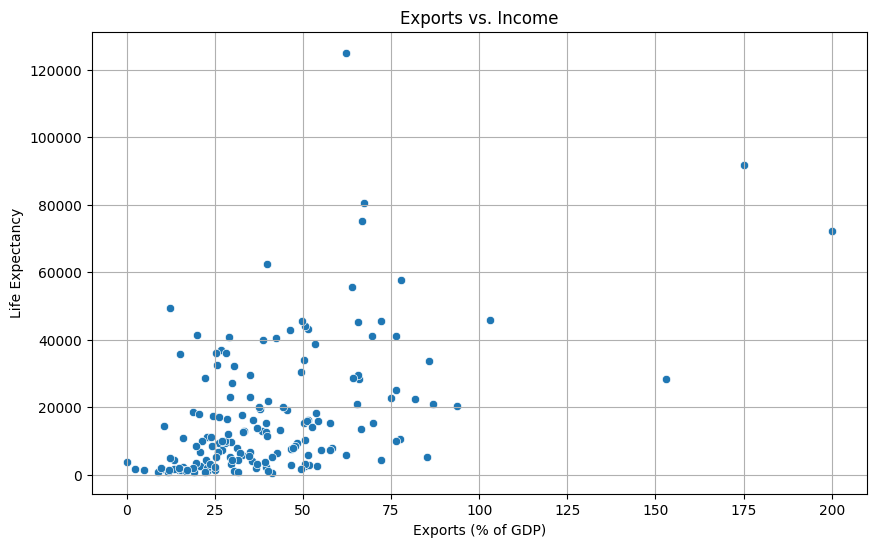

In [79]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='exports', y='income', data=df)
plt.title('Exports vs. Income')
plt.xlabel('Exports (% of GDP)')
plt.ylabel('Life Expectancy')
plt.grid(True)
plt.show()

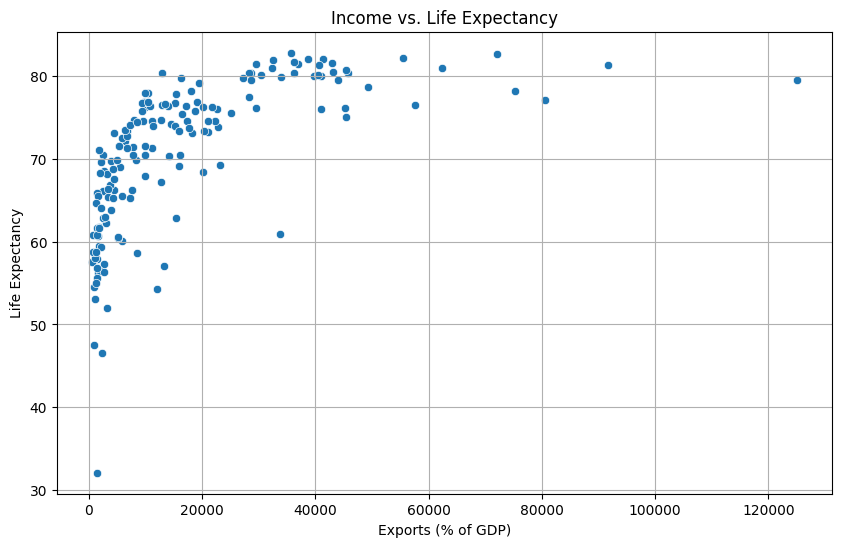

In [80]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='income', y='life_expec', data=df)
plt.title('Income vs. Life Expectancy')
plt.xlabel('Exports (% of GDP)')
plt.ylabel('Life Expectancy')
plt.grid(True)
plt.show()

In [126]:
import plotly.express as px

X = scaled_numerical

agg_clustering = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['Cluster'] = agg_clustering.fit_predict(scaled_numerical)

print('Cluster Frequencies:')
print(df['Cluster'].value_counts())
print('Output Clusters are')
pred1 = model_clt.labels_
print(pred1)
unique, counts = np.unique(pred1, return_counts=True)
print(dict(zip(unique, counts)))

fig = px.scatter_3d(df, x='exports', y='life_expec', z='income', color=agg_clustering.labels_)
fig.show()

Cluster Frequencies:
Cluster
1    106
0     34
2     27
Name: count, dtype: int64


Identify 2–3 variables that appear strongly correlated `(10 pts)`
- Explain your observations in the text cell below.

exports, life_expec, income

**Income and Life Expectancy:** These two features are strongly positively correlated. Countries with higher average incomes generally have better healthcare systems, access to nutritious food, improved sanitation, and higher educational attainment, all of which contribute to longer life expectancies.

**Income and Exports:** Income and exports often show a positive relationship. More developed and higher-income economies tend to have diverse and competitive industries, leading to higher export volumes and values. Successful export sectors can also contribute significantly to a country's national income.

**Exports and Life Expectancy:** While not as direct as income and life expectancy, there can be an indirect positive correlation. Countries with strong export economies often have more stable and growing economies, which can lead to increased government revenue. This revenue can then be invested in public services like healthcare and education, ultimately improving the quality of life and extending life expectancy for the population.


## 6. Hierarchical Clustering

Compute and display a dendrogram using the linkage method `(10 pts)`
- Use `'ward'` linkage to minimize variance within clusters.

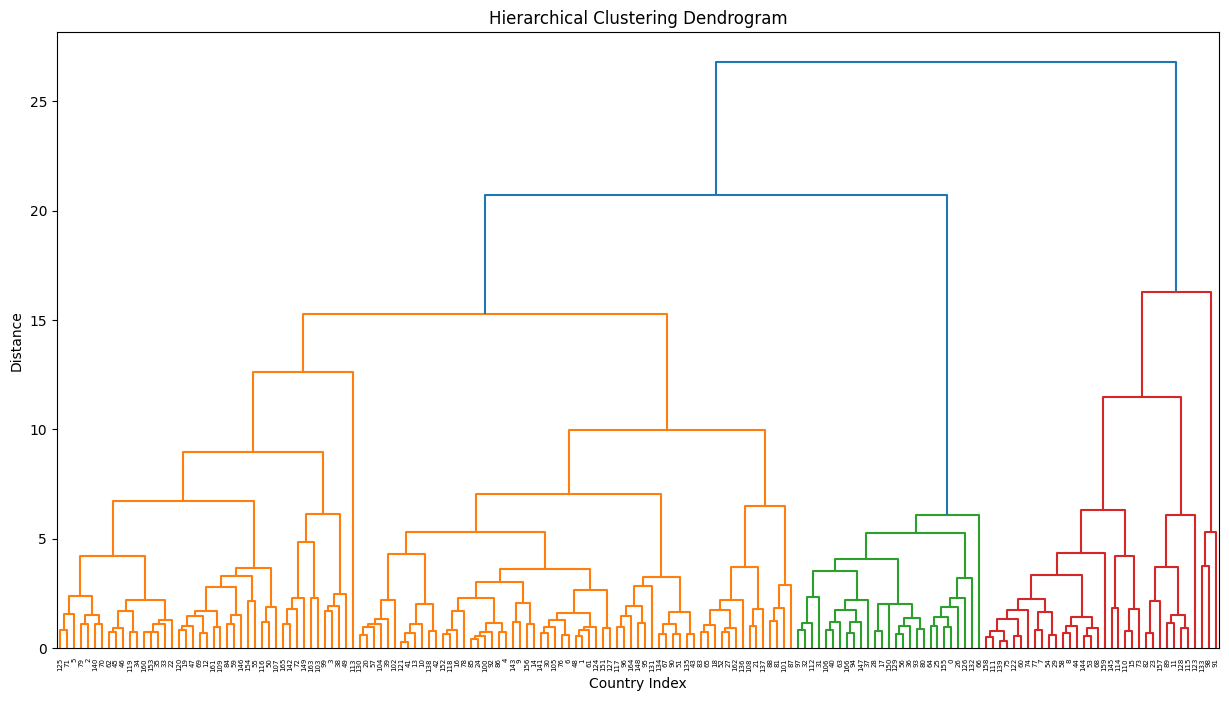

In [82]:
linked = linkage(scaled_numerical, method='ward')

plt.figure(figsize=(15, 8))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Country Index')
plt.ylabel('Distance')
plt.show()

Based on the dendrogram, choose a reasonable number of clusters `(5 pts)`
- Write your chosen number below and explain your reasoning.

Based on the dendrogram, I have identified 3 clusters, I determine the number of clusters by looking for the longest vertical lines that can be crossed by a horizontal line without intersecting other lines too soon.

Perform Agglomerative Clustering using your chosen cluster count `(10 pts)`
- Attach the cluster labels back to the original dataframe.

In [107]:
agg_clustering = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['Cluster'] = agg_clustering.fit_predict(scaled_numerical)

print(df.head(10))

print('Cluster Frequencies:')
print(df['Cluster'].value_counts())

               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   
5            Argentina        14.5     18.9    8.10     16.0   18700   
6              Armenia        18.1     20.8    4.40     45.3    6700   
7            Australia         4.8     19.8    8.73     20.9   41400   
8              Austria         4.3     51.3   11.00     47.8   43200   
9           Azerbaijan        39.2     54.3    5.88     20.7   16000   

   inflation  life_expec  total_fer   gdpp  Cluster  
0      9.440        56.2       5.82    553        2  
1      4.490        76.3       1.65   4090        1  
2     16.100        76.5       2.89   4460   

## 7. Visualizing Cluster Results

Create a scatter plot using any 2 meaningful features, colored by cluster `(10 pts)`
- Choose variables that make socioeconomic sense (e.g., GDP per capita vs. life expectancy).

In [138]:
import plotly.express as px

fig = px.scatter_3d(df, x='exports', y='life_expec', z='income', color='Cluster', title='Clusters by Exports, Life Expectancy, and Income', labels={'exports': 'Exports (% of GDP)', 'life_expec': 'Life Expectancy', 'income': 'Income per Capita'})
fig.show()

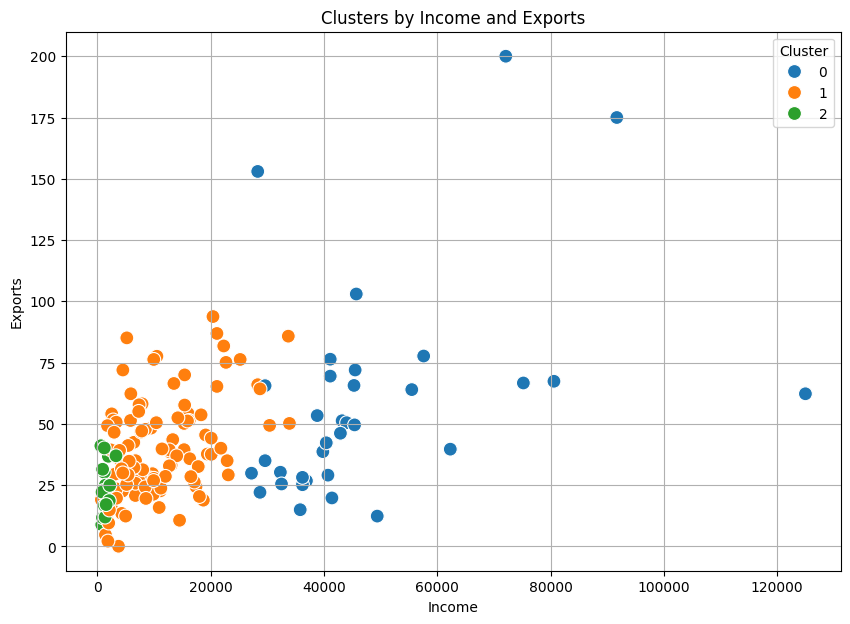

In [119]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='income', y='exports', hue='Cluster', data=df, palette='tab10', s=100)
plt.title('Clusters by Income and Exports')
plt.xlabel('Income')
plt.ylabel('Exports')
plt.grid(True)
plt.legend(title='Cluster')
plt.show()

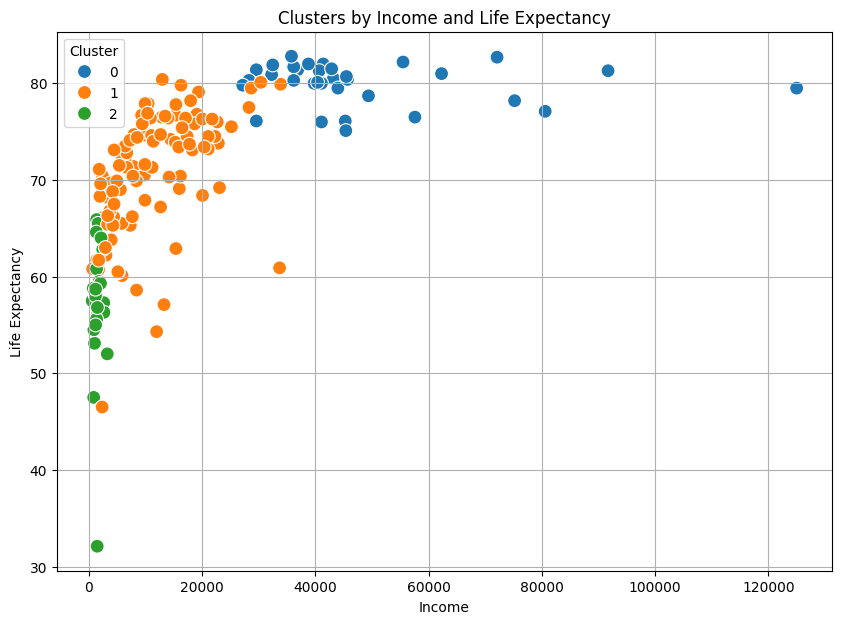

In [137]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='income', y='life_expec', hue='Cluster', data=df, palette='tab10', s=100)
plt.title('Clusters by Income and Life Expectancy')
plt.xlabel('Income')
plt.ylabel('Life Expectancy')
plt.grid(True)
plt.legend(title='Cluster')
plt.show()

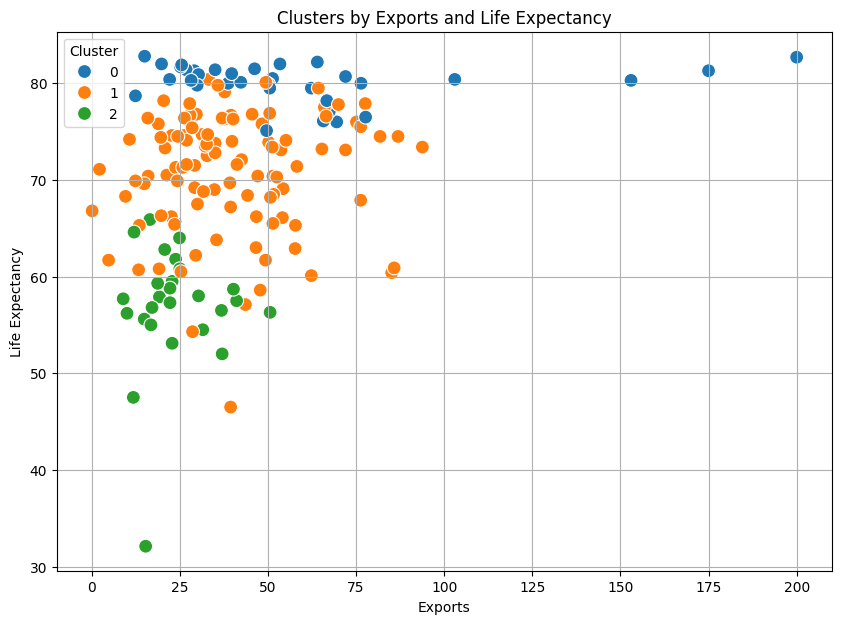

In [143]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='exports', y='life_expec', hue='Cluster', data=df, palette='tab10', s=100)
plt.title('Clusters by Exports and Life Expectancy')
plt.xlabel('Exports')
plt.ylabel('Life Expectancy')
plt.grid(True)
plt.legend(title='Cluster')
plt.show()

Describe the characteristics of each cluster `(5 pts)`
- What patterns can you infer about country groupings?

In [139]:
cluster_characteristics = df.groupby('Cluster')[numerical.columns].mean()
display(cluster_characteristics)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,5.961765,58.508824,8.501176,48.902941,47588.235294,4.115500,79.982353,1.888529,43170.588235
1,31.617925,39.990368,6.353679,48.085527,11341.886792,9.120604,70.921698,2.654623,6407.367925
2,105.070370,23.589630,6.507037,39.662963,1589.740741,7.142778,57.248148,5.433704,667.888889


Here are the patterns about country groupings based on the cluster characteristics:

**Cluster 0 (Developed Countries):**
- **Low child mortality:** Very low `child_mort` indicates advanced healthcare and living conditions.
- **High exports and imports:** Signifies well-integrated economies with strong international trade.
- **High health expenditure:** A significant portion of GDP dedicated to `health` reflects robust healthcare systems.
- **Very high income and GDPP:** These countries have the highest average `income` and `gdpp`, indicating economic prosperity.
- **Low inflation:** Stable economic environments.
- **High life expectancy:** Longest `life_expec` due to better healthcare, nutrition, and living standards.
- **Low total fertility:** Typically seen in developed nations with access to family planning and higher education for women.

**Cluster 1 (Emerging Countries):**
- **Medium child mortality:** Higher than developed but lower than least developed, suggesting ongoing improvements in health.
- **Moderate exports and imports:** Engaged in international trade but perhaps not as extensively diversified or integrated as developed nations.
- **Moderate health expenditure:** A reasonable amount spent on health, but potentially with room for improvement.
- **Moderate income and GDPP:** These countries fall in the middle range for `income` and `gdpp`, indicating a developing economy.
- **Moderate inflation:** More volatile economic conditions compared to developed countries.
- **Moderate life expectancy:** Better than least developed but not as high as developed nations.
- **Moderate total fertility:** Fertility rates are higher than developed countries but often decreasing as development progresses.

**Cluster 2 (Least Developed Countries):**
- **Very high child mortality:** The highest `child_mort` rates, pointing to severe challenges in healthcare, sanitation, and nutrition.
- **Low exports and imports:** Limited participation in global trade, often relying on a few primary commodities.
- **Low health expenditure:** A smaller percentage of GDP allocated to `health`, indicating inadequate healthcare infrastructure.
- **Very low income and GDPP:** These countries have the lowest average `income` and `gdpp`, signifying poverty and economic hardship.
- **High inflation:** Often experience significant economic instability.
- **Low life expectancy:** The lowest `life_expec`, reflecting poor living conditions and healthcare.
- **High total fertility:** The highest `total_fer`, often linked to lack of access to education, family planning, and high child mortality rates.

In summary, the hierarchical clustering successfully grouped countries into three distinct categories based on their socioeconomic indicators, broadly aligning with 'developed,' 'developing/emerging,' and 'least developed' country classifications.

## 8. Reflection
Write a short reflection on what socioeconomic insights hierarchical clustering revealed about global development patterns. `(10 pts)`


Hierarchical clustering provides a strong lens to view global development patterns, effectively categorizing countries into distinct groups based on their socioeconomic indicators.

1.  **Developed Countries (Cluster 0):** Characterized by low child mortality, high income, high life expectancy, and robust trade. These countries exhibit strong healthcare systems, stable economies, and advanced social welfare, consistent with well-established developed nations.

2.  **Developing/Emerging Countries (Cluster 1):** Occupying a middle ground, these nations show moderate child mortality, income, and life expectancy. They are engaged in global trade, but their economies are often more volatile and health indicators are still improving, reflecting ongoing development efforts.

3.  **Least Developed Countries (Cluster 2):** Marked by very high child mortality, low income, low life expectancy, and limited global trade participation. These countries face significant challenges in healthcare, economic stability, and overall quality of life, highlighting areas requiring substantial international development support.

Overall, the clustering demonstrates that socioeconomic indicators are highly interdependent. Factors like income, health, and trade collectively define a country's developmental stage. This method allows for a data-driven understanding of global disparities and can help international organizations tailor interventions and policies to the specific needs of each country group, rather than adopting a one-size-fits-all approach. It underscores the multifaceted nature of development and the persistent gaps between nations.